In [2]:
import numpy as np
import numpy as np
import torch
import sys, os
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
from datasets.data import SpatialDataset
from datasets.transformerRegressorDataClass import TransformerPointDataset, collate_point_batches
from torch.utils.data import DataLoader
#from datasets.dt2_data import load_dt2_data
from models.transformerRegressor import TransformerCLSRegressor
import numpy as np
import matplotlib.pyplot as plt
from argument_transformer import parse_opt

/home/user_116/Project-B-Technion/Transformer_Map_Interp


In [3]:
@torch.no_grad()
def evaluate_split(model, dataset, trainset, device):
    ds = TransformerPointDataset(dataset, trainset, device=device)
    loader = DataLoader(ds, batch_size=32, shuffle=False, collate_fn=collate_point_batches)

    preds, trues, coords = [], [], []
    y_mean, y_std = trainset.y_mean.to(device), trainset.y_std.to(device)

    model.eval()
    for mem, mask, y, cls_coord in loader:
        mem, mask, y = mem.to(device), mask.to(device), y.to(device)
        y_hat = model(mem, mask)

        # denormalize
        y_hat_real = y_hat * y_std + y_mean
        y_real = y * y_std + y_mean

        preds.append(y_hat_real.cpu())
        trues.append(y_real.cpu())
        coords.append(cls_coord.cpu())

    preds = torch.cat(preds)
    trues = torch.cat(trues)
    coords = torch.cat(coords)

    abs_err = torch.abs(preds - trues)
    #rel_err = abs_err / (torch.abs(trues) + 1e-6)
    return coords, abs_err#, rel_err


def plot_error_map(coords, errors, title="Error map", cmap="inferno"):
    plt.figure(figsize=(10,8))
    sc = plt.scatter(coords[:,1], coords[:,0], c=errors, s=6, cmap=cmap)
    plt.colorbar(sc, label="Absolute Error (m)")
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.title(title)
    plt.show()

In [ ]:
# Show the current working directory
from pathlib import Path
print(os.getcwd())
os.chdir("..")
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
p_cache = Path("cache")
print("cache exists?", p_cache.exists(), "->", p_cache.resolve())
trainset = torch.load(r"./cache/trainset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.05_seed5.pt",map_location="cpu",weights_only=False)
validset = torch.load(r"./cache/validset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.05_seed5.pt",map_location="cpu",weights_only=False)
testset = torch.load(r"./cache/testset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.05_seed5.pt",map_location="cpu",weights_only=False)

/home/user_116/Project-B-Technion/Transformer_Map_Interp/display
/home/user_116/Project-B-Technion
cache exists? True -> /home/user_116/Project-B-Technion/Transformer_Map_Interp/cache


In [75]:
# Show the current working directory
from pathlib import Path
print(os.getcwd())
#os.chdir("..")
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
p_cache = Path("cache")
print("cache exists?", p_cache.exists(), "->", p_cache.resolve())
trainset = torch.load(r"./cache/trainset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.005_seed5.pt",map_location="cpu",weights_only=False)
validset = torch.load(r"./cache/validset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.005_seed5.pt",map_location="cpu",weights_only=False)
testset = torch.load(r"./cache/testset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.005_seed5.pt",map_location="cpu",weights_only=False)

/home/user_116/Project-B-Technion/Transformer_Map_Interp
/home/user_116/Project-B-Technion
cache exists? True -> /home/user_116/Project-B-Technion/Transformer_Map_Interp/cache


In [77]:
import argparse
import torch
argv_bak = sys.argv
try:
    sys.argv = [argv_bak[0]]  # keep program name only; drop Jupyter’s flags
    args = parse_opt()
finally:
    sys.argv = argv_bak
args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.dropout = 0.0
args.model = "transformer"
in_dim = 3  # [Δlat, Δlon, y_known_norm, is_observed] # Orit 12.10 from 4 --> 3
print("Using device:", args.device)
model = TransformerCLSRegressor(
    in_dim=in_dim,
    d_model=args.d_model,
    nhead=args.n_heads,       # keep your arg names as-is
    num_layers=args.n_layers, # keep your arg names as-is
    dim_feedforward=args.ffn_dim,
    dropout=args.dropout,
    #cls_init=args.cls_init,
    use_posenc=args.use_posenc,
).to(args.device)
print("Model initialized:")
print(model)
sys.path.append(os.path.abspath("../"))  # project root
print(os.path.abspath("../"))
print("Current working directory:", os.getcwd())
print("File exists?", os.path.exists("../saved_models/Exp_4/best_model_13.pt"))
ckpt_path = f"../saved_models/Exp_3/Final_Train/best_model_27.pt"
last_path = f"../saved_models/Exp_3/Final_Train/last_epoch_model.pt"
print(f"Loading checkpoint from {ckpt_path}")
model.load_state_dict(torch.load(ckpt_path, map_location=args.device))

device: cuda
Using device: cuda
Model initialized:
TransformerCLSRegressor(
  (in_proj): Linear(in_features=3, out_features=256, bias=True)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=256, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=Fal

<All keys matched successfully>

Display the errors as error map

In [78]:
@torch.no_grad()
def predict(dataset, trainset):
    ds = TransformerPointDataset(dataset, trainset, device=args.device)
    loader = DataLoader(ds, batch_size=64, shuffle=False, collate_fn=collate_point_batches)
    preds, trues, coords = [], [], []

    for mem, mask, y, cls_coords in loader:
        mem, mask = mem.to(args.device), mask.to(args.device)
        y_hat = model(mem, mask)
        y_hat_real = y_hat * trainset.y_std + trainset.y_mean
        y_real = y * trainset.y_std + trainset.y_mean
        preds.append(y_hat_real.cpu())
        trues.append(y_real.cpu())
        coords.append(cls_coords.cpu())

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    coords = torch.cat(coords).numpy()
    errors = preds - trues
    return coords, trues, preds, errors


In [79]:
val_coords, val_true, val_pred, val_err = predict(validset, trainset)
test_coords, test_true, test_pred, test_err = predict(testset, trainset)

In [80]:
def plot_error_map(coords, true, err, title_prefix,
                   cmap_elev="terrain", cmap_err="coolwarm",
                   elev_norm=None, err_norm=None, save_name=None):
    lons, lats = coords[:,1], coords[:,0]
    fig, axs = plt.subplots(2, 1, figsize=(9, 12), constrained_layout=True)

    # Top: original elevation (shared color scale)
    sc1 = axs[0].scatter(lons, lats, c=true, cmap=cmap_elev, s=6, norm=elev_norm)
    axs[0].set_title(f"{title_prefix} – Original Elevation")
    axs[0].set_xlabel("Longitude"); axs[0].set_ylabel("Latitude")
    plt.colorbar(sc1, ax=axs[0], label="Elevation (m)")

    # Bottom: error (shared, centered at 0)
    sc2 = axs[1].scatter(lons, lats, c=err, cmap=cmap_err, s=6, norm=err_norm)
    axs[1].set_title(f"{title_prefix} – Prediction Error (Pred - True)")
    axs[1].set_xlabel("Longitude"); axs[1].set_ylabel("Latitude")
    plt.colorbar(sc2, ax=axs[1], label="Error (m)")

    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()


In [81]:
from matplotlib.colors import Normalize, TwoSlopeNorm

# 1) Elevation uses the SAME vmin/vmax across val+test
elev_min = float(min(val_true.min(), test_true.min()))
elev_max = float(max(val_true.max(), test_true.max()))
elev_norm = Normalize(vmin=elev_min, vmax=elev_max)

# 2) Error uses a symmetric scale around 0, shared across val+test
err_abs_max = float(np.max(np.abs(np.concatenate([val_err.ravel(), test_err.ravel()]))))
err_norm = TwoSlopeNorm(vmin=-err_abs_max, vcenter=0.0, vmax=err_abs_max)

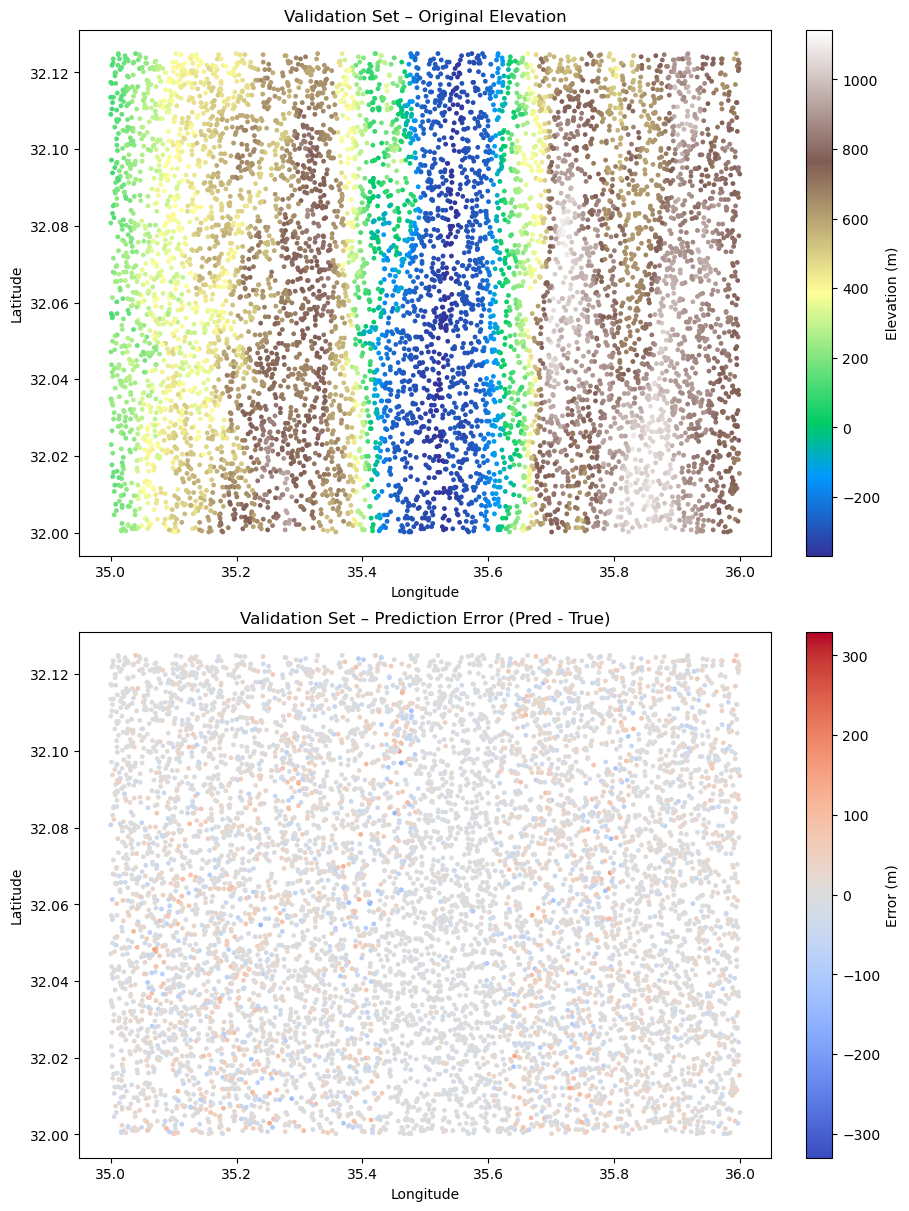

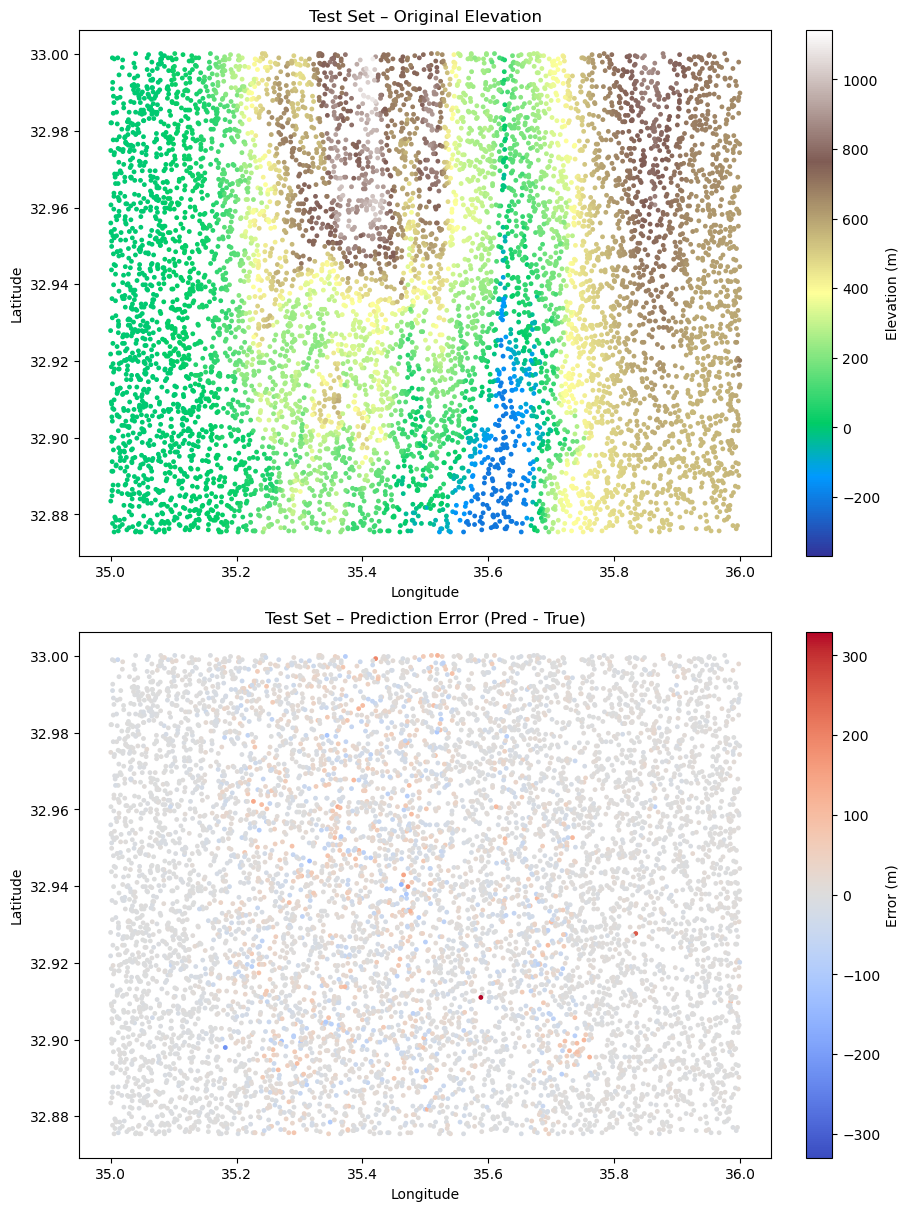

In [82]:
plot_error_map(val_coords,  val_true,  val_err,  "Validation Set",
               elev_norm=elev_norm, err_norm=err_norm, save_name="val_error_map.png")

plot_error_map(test_coords, test_true, test_err, "Test Set",
               elev_norm=elev_norm, err_norm=err_norm, save_name="test_error_map.png")


Display some test's point compared to the GT

In [83]:
import random
def plot_random_point_comparison(coords, y_true, y_pred, n_samples=40, seed=42):
    """
    Shows random points from the test set:
      - x-axis: Point index (random order)
      - y-axis: Elevation (m)
      - Blue dots = GT
      - Orange dots = Predicted
      - Thin gray lines connect each pair
    """
    random.seed(seed)
    idxs = random.sample(range(len(coords)), min(n_samples, len(coords)))

    # Extract subsets
    y_true_s = y_true[idxs].flatten()
    y_pred_s = y_pred[idxs].flatten()

    plt.figure(figsize=(10, 6))
    x = np.arange(len(idxs))

    # Plot connections (errors)
    for i in range(len(x)):
        plt.plot([x[i], x[i]], [y_true_s[i], y_pred_s[i]], color="gray", alpha=0.4, lw=1)

    plt.scatter(x, y_true_s, color="royalblue", label="Ground Truth", alpha=0.8, s=45)
    plt.scatter(x, y_pred_s, color="darkorange", label="Prediction", alpha=0.8, s=45)

    plt.title("Random Sample: Ground Truth vs Predicted Elevations (Test Set)")
    plt.ylabel("Elevation (m)")
    plt.xlabel("Random Sample Index")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



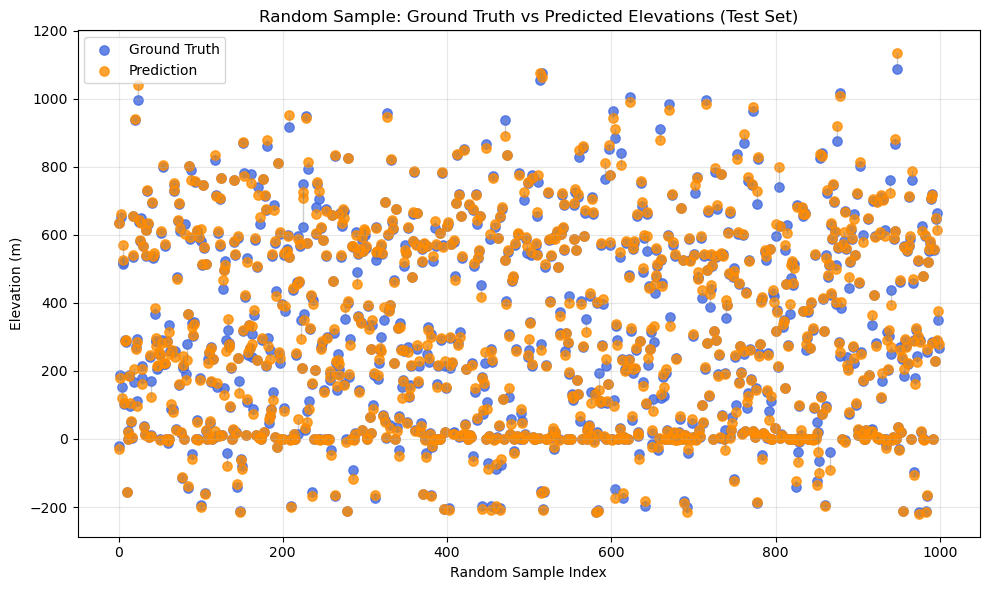

In [24]:
plot_random_point_comparison(test_coords, test_true, test_pred, n_samples=1000, seed=42)

In [84]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D plotting)
from scipy.interpolate import griddata
def add_wireframe(ax, coords, y_true, step=80):
    lats, lons, z = coords[:,0], coords[:,1], y_true.flatten()
    lon_lin = np.linspace(lons.min(), lons.max(), step)
    lat_lin = np.linspace(lats.min(), lats.max(), step)
    lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)
    z_grid = griddata((lons, lats), z, (lon_grid, lat_grid), method='linear')
    ax.plot_wireframe(lon_grid, lat_grid, z_grid, color='gray', alpha=0.2, rstride=4, cstride=4)
    
def plot_3d_cloud(coords, y_true, y_pred, n_points=3000,seed=42):
    """
    3D scatter plot of test set elevations.
    - Blue: Ground Truth
    - Orange: Predicted
    You can rotate the 3D view to inspect terrain structure.
    """
    random.seed(seed)
    # Subsample for clarity
    if len(coords) > n_points:
        idx = np.random.choice(len(coords), n_points, replace=False)
    else:
        idx = np.arange(len(coords))

    lats = coords[idx, 0]
    lons = coords[idx, 1]
    y_true_s = y_true[idx].flatten()
    y_pred_s = y_pred[idx].flatten()

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Ground truth
    ax.scatter(lons, lats, y_true_s, c='royalblue', label='Ground Truth', s=10, alpha=0.7)

    # Predictions
    ax.scatter(lons, lats, y_pred_s, c='darkorange', label='Prediction', s=10, alpha=0.7)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Elevation (m)")
    ax.set_title("3D Point Cloud: Ground Truth vs Predicted Elevations (Test Set)")

    ax.legend()
    #add_wireframe(ax, coords[idx], y_true_s)
    plt.tight_layout()
    plt.show()


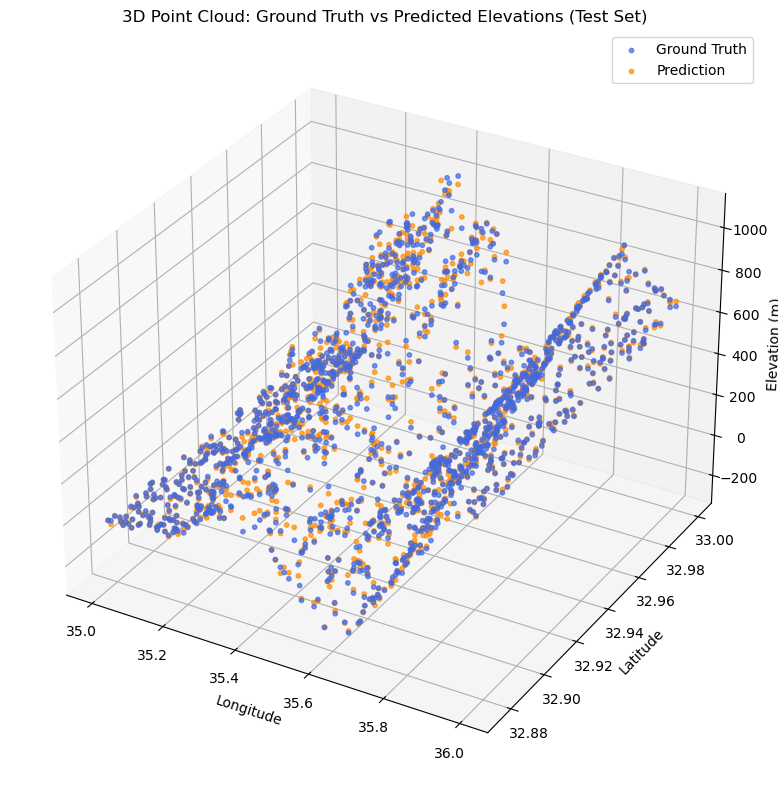

In [85]:
plot_3d_cloud(test_coords, test_true, test_pred, n_points=1500)

In [73]:
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_surface(coords, y_true, title, step=300):
    """Interpolates both GT and predicted surfaces and shows them as two translucent layers."""
    lats, lons = coords[:,0], coords[:,1]
    z_true = y_true.flatten()#, y_pred.flatten()

    lon_lin = np.linspace(lons.min(), lons.max(), step)
    lat_lin = np.linspace(lats.min(), lats.max(), step)
    lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)
    z_true_grid = griddata((lons, lats), z_true, (lon_grid, lat_grid), method='linear')
    #z_pred_grid = griddata((lons, lats), z_pred, (lon_grid, lat_grid), method='linear')

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    s1 = ax.plot_surface(lon_grid, lat_grid, z_true_grid, cmap='terrain', alpha=0.8, linewidth=0)
    #fig.colorbar(s1, ax, label="Elevation (m)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_zlabel("Elevation (m)")
    ax.set_title(f"{title}")
    plt.tight_layout()
    plt.show()


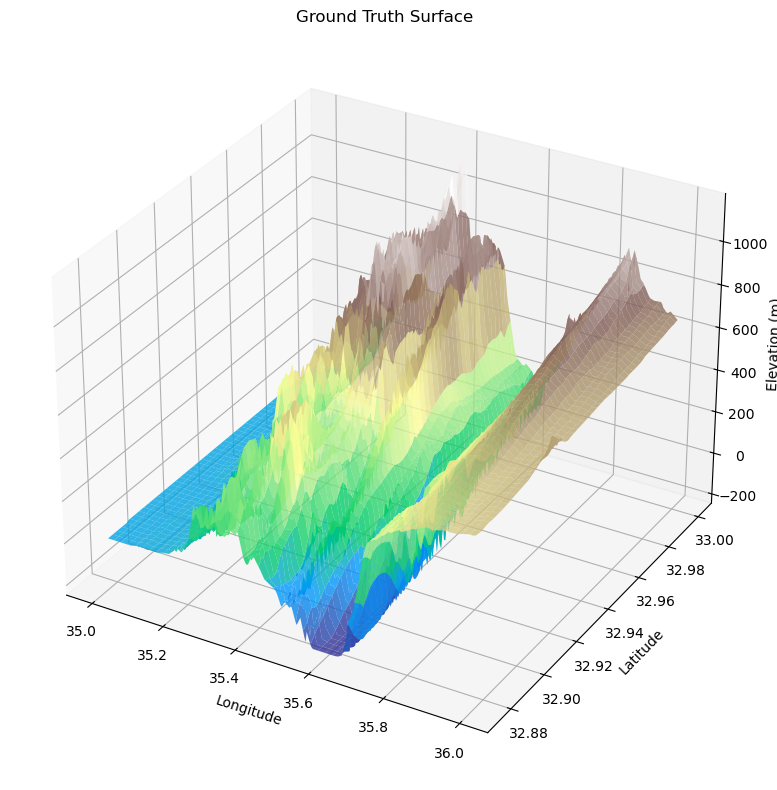

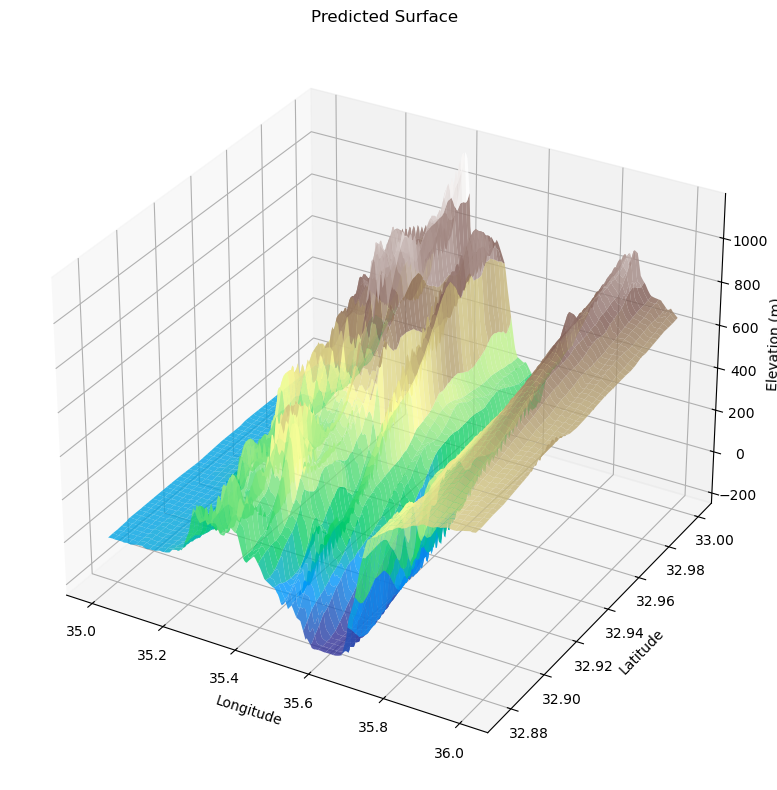

In [74]:
plot_3d_surface(test_coords, test_true, title="Ground Truth Surface")
plot_3d_surface(test_coords, test_pred, title="Predicted Surface")

In [50]:
from scipy.interpolate import griddata
from matplotlib.colors import Normalize

def plot_3d_gt_and_pred_separate(coords, y_true, y_pred, step=100,
                                 cmap="Purples", titles=("Ground Truth", "Prediction"),
                                 save_prefix=None):
    """
    Makes two 3D surface figures (GT and Pred) with a shared colormap scale.
    coords: (N,2) [lat, lon]
    y_true, y_pred: (N,) or (N,1) elevations in meters
    step: grid resolution for interpolation
    """
    lats = coords[:, 0]
    lons = coords[:, 1]
    z_true = y_true.reshape(-1)
    z_pred = y_pred.reshape(-1)

    # Build shared grid
    lon_lin = np.linspace(lons.min(), lons.max(), step)
    lat_lin = np.linspace(lats.min(), lats.max(), step)
    lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

    # Interpolate both onto the SAME grid
    z_true_grid = griddata((lons, lats), z_true, (lon_grid, lat_grid), method="linear")
    z_pred_grid = griddata((lons, lats), z_pred, (lon_grid, lat_grid), method="linear")

    # Shared color normalization (same min/max for both)
    vmin = float(np.nanmin([z_true_grid.min(), z_pred_grid.min()]))
    vmax = float(np.nanmax([z_true_grid.max(), z_pred_grid.max()]))
    norm = Normalize(vmin=vmin, vmax=vmax)

    # --- Figure 1: GT ---
    fig1 = plt.figure(figsize=(9, 7))
    ax1 = fig1.add_subplot(111, projection='3d')
    s1 = ax1.plot_surface(lon_grid, lat_grid, z_true_grid, cmap=cmap, norm=norm, linewidth=0)
    ax1.set_xlabel("Longitude"); ax1.set_ylabel("Latitude"); ax1.set_zlabel("Elevation (m)")
    ax1.set_title(titles[0])
    cbar1 = fig1.colorbar(s1, ax=ax1, shrink=0.65, pad=0.08)
    cbar1.set_label("Elevation (m)")
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_GT.png", dpi=300, bbox_inches="tight")
    plt.show()

    # --- Figure 2: Pred ---
    fig2 = plt.figure(figsize=(9, 7))
    ax2 = fig2.add_subplot(111, projection='3d')
    s2 = ax2.plot_surface(lon_grid, lat_grid, z_pred_grid, cmap=cmap, norm=norm, linewidth=0)
    ax2.set_xlabel("Longitude"); ax2.set_ylabel("Latitude"); ax2.set_zlabel("Elevation (m)")
    ax2.set_title(titles[1])
    cbar2 = fig2.colorbar(s2, ax=ax2, shrink=0.65, pad=0.08)
    cbar2.set_label("Elevation (m)")
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_PRED.png", dpi=300, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_687896/659916305.py:28: RuntimeWarning: All-NaN axis encountered
  vmin = float(np.nanmin([z_true_grid.min(), z_pred_grid.min()]))
/tmp/ipykernel_687896/659916305.py:29: RuntimeWarning: All-NaN axis encountered
  vmax = float(np.nanmax([z_true_grid.max(), z_pred_grid.max()]))


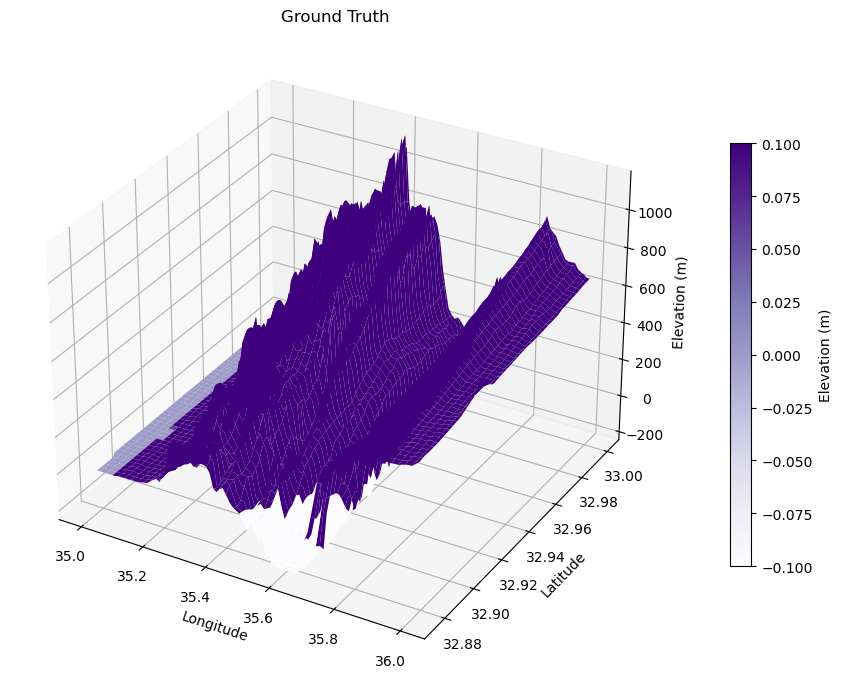

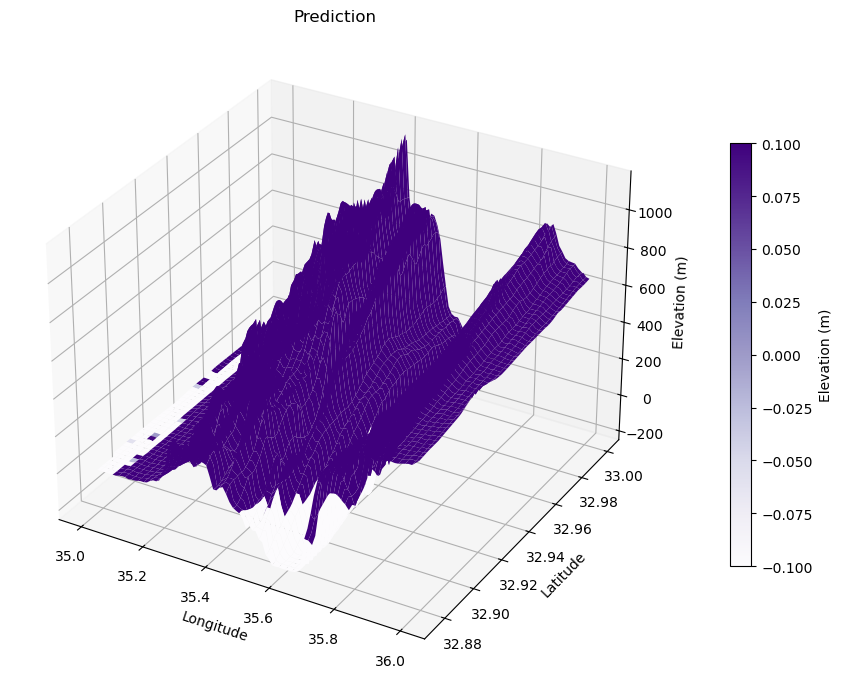

In [51]:
plot_3d_gt_and_pred_separate(test_coords, test_true, test_pred)